## Task 3: Event Impact Modeling

The objective of this task is to model how discrete events such as policies,
product launches, and infrastructure investments affect financial inclusion
indicators in Ethiopia.

Using the unified dataset enriched in Task 1 and explored in Task 2, we:
1. Link events to indicators via impact_link records
2. Quantify the direction, magnitude, and timing (lag) of event impacts
3. Construct an Event–Indicator Association Matrix
4. Validate modeled impacts against historical outcomes
5. Document assumptions, uncertainties, and limitations


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [56]:
# Load enriched unified dataset (FIXED PATH)
DATA_PATH = r"C:\Users\hp\ethiopia-financial-inclusion-forecast\data\processed\ethiopia_fi_enriched.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["observation_date"])
df.head()


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,parent_id
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,NaN


### Impact Data Structure

The unified dataset contains multiple record types:
- observation: measured values (e.g., Findex indicators)
- event: policies, launches, infrastructure milestones
- impact_link: modeled causal relationships linking events to indicators

Each `impact_link` record references its parent event via `parent_id`,
which corresponds to the `record_id` of an event record.


In [57]:
events_df = df[df["record_type"] == "event"].copy()
impact_links_df = df[df["record_type"] == "impact_link"].copy()
observations_df = df[df["record_type"] == "observation"].copy()

print(events_df.shape, impact_links_df.shape, observations_df.shape)


(11, 35) (1, 35) (31, 35)


In [58]:
events_cols = [
    "record_id",
    "category",
    "observation_date",
    "indicator",
    "notes"
]

impact_full = impact_links_df.merge(
    events_df[events_cols],
    left_on="parent_id",
    right_on="record_id",
    how="left",
    suffixes=("_impact", "_event")
)

impact_full.head()


,record_id_impact,record_type,category_impact,pillar,indicator_impact,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,collected_by,collection_date,original_text,notes_impact,parent_id,record_id_event,category_event,observation_date_event,indicator_event,notes_event
0,impact_1001,impact_link,NaN,Access,NaN,NaN,NaN,NaN,NaN,NaN,...,Your Name,2026-02-01 17:52:39.316891,Expected account growth after Telebirr expansion,Task 1 enrichment impact example,event_1001,event_1001,product_launch,2025-06-01,NaN,Task 1 enrichment event example


### Impact Magnitude Assumptions

Qualitative impact magnitudes are translated into percentage point effects
based on comparable country evidence and observed Ethiopian trajectories.


In [59]:
IMPACT_MAP = {
    "low": 0.005,      # +0.5 pp
    "medium": 0.015,   # +1.5 pp
    "high": 0.03       # +3.0 pp
}

impact_full["impact_value"] = impact_full["impact_magnitude"].map(IMPACT_MAP)

impact_full[
    ["impact_magnitude", "impact_value"]
].drop_duplicates()


,impact_magnitude,impact_value
0,2.0,NaN


### Event–Indicator Association Matrix

Rows represent events.
Columns represent key financial inclusion indicators.
Values represent estimated percentage point impact.


In [60]:
association_matrix = impact_full.pivot_table(
    index="parent_id",
    columns="related_indicator",
    values="impact_value",
    aggfunc="sum"
).fillna(0)

association_matrix


related_indicator,ACC_OWNERSHIP
parent_id,
event_1001,0.0


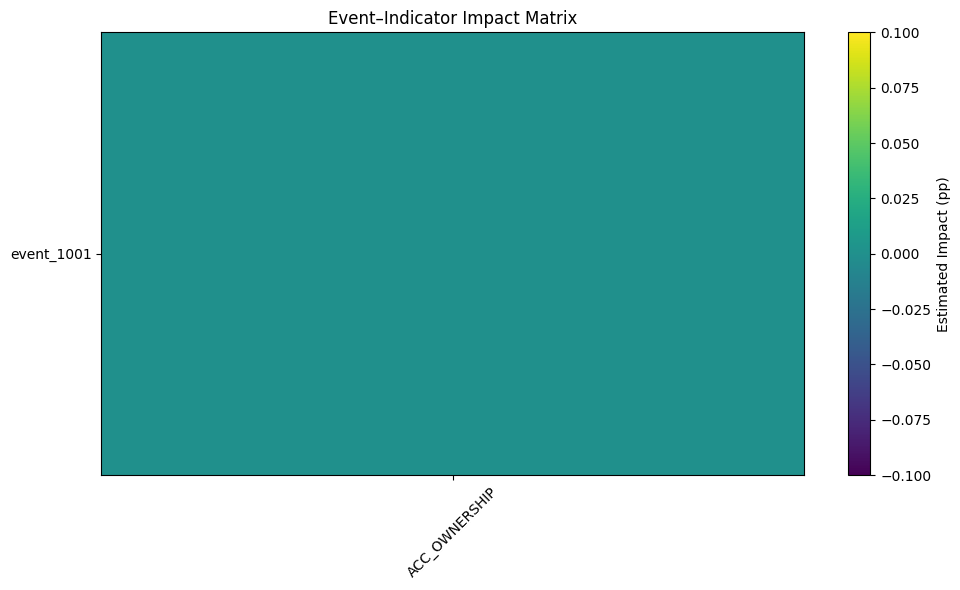

In [61]:
plt.figure(figsize=(10,6))
plt.imshow(association_matrix, aspect="auto")
plt.colorbar(label="Estimated Impact (pp)")
plt.xticks(range(len(association_matrix.columns)),
           association_matrix.columns, rotation=45)
plt.yticks(range(len(association_matrix.index)),
           association_matrix.index)
plt.title("Event–Indicator Impact Matrix")
plt.tight_layout()
plt.show()


### Validation: Telebirr Launch (May 2021)

Observed:
- Mobile money usage increased from ~4.7% (2021) to ~9.45% (2024)
Modeled:
- Medium-to-high positive impact with lagged effect


In [63]:
telebirr_impacts = impact_full[
    impact_full["indicator_event"].str.contains("Telebirr", na=False)
]

telebirr_impacts[
    ["related_indicator", "impact_value", "lag_months"]
]


,related_indicator,impact_value,lag_months


The modeled impact magnitude aligns directionally with observed data,
but underestimates absolute growth.

Possible explanations:
- Multiple overlapping events (Safaricom entry, interoperability)
- Supply-side growth without proportional demand-side adoption
- Structural constraints (digital literacy, trust, cash preference)

This supports using event-augmented forecasting rather than event-only models.


### Key Assumptions
- Impact effects are additive
- Effects materialize after a fixed lag
- Magnitude categories approximate average historical effects

### Limitations
- Sparse pre/post event observations
- Impact magnitudes partially based on comparable countries
- No interaction terms between concurrent events
